# 📦 Supply Chain Analytics — Just In Time
### End-to-End Python Analysis | Data Cleaning · EDA · Feature Engineering · ABC Segmentation

> **Dataset period:** 2015–2017 | **Rows:** 30,871 orders · 4,200 inventory records · 118 fulfillment entries  
> **Goal:** Identify shipment delays, inventory imbalances, and profit inefficiencies to drive actionable business improvements.

---


## 1. Setup & Data Loading

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})

print("Libraries loaded ✅")


Libraries loaded ✅


In [89]:
# ── Load datasets (relative paths — works on any machine) ───────────────────
df_orders      = pd.read_csv('Datasets/orders_and_shipment.csv', encoding='ISO-8859-1')
df_inventory   = pd.read_csv('Datasets/inventory.csv')
df_fulfillment = pd.read_csv('Datasets/fulfillment.csv')

print(f"Orders      : {df_orders.shape[0]:,} rows × {df_orders.shape[1]} cols")
print(f"Inventory   : {df_inventory.shape[0]:,} rows × {df_inventory.shape[1]} cols")
print(f"Fulfillment : {df_fulfillment.shape[0]:,} rows × {df_fulfillment.shape[1]} cols")


Orders      : 30,871 rows × 20 cols
Inventory   : 4,200 rows × 4 cols
Fulfillment : 118 rows × 2 cols


## 2. First Look at the Data
Before any cleaning, we take a quick peek at structure, types, and obvious anomalies.


In [90]:
df_orders.head()

,Order ID,Order Item ID,Order YearMonth,Order Quantity,Product Department,Product Category,Product Name,Customer ID,Customer Market,Customer Region,Customer Country,Warehouse Country,Shipment Mode,Shipment Days - Scheduled,Gross Sales,Discount %,Profit,Order Datetime,Shipment Datetime,Order Processing Time
0,3535,8793,201502,1,Fan Shop,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,7840,LATAM,Central America,Mexico,Puerto Rico,Standard Class,4,400,0.25,200,2015-02-21 14:07:00,2015-02-27,5
1,4133,10320,201503,1,Fan Shop,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,1203,LATAM,South America,Brazil,Puerto Rico,Standard Class,4,400,0.09,200,2015-03-02 07:37:00,2015-03-06,3
2,7396,18517,201504,1,Fan Shop,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,10866,LATAM,Central America,Mexico,Puerto Rico,Standard Class,4,400,0.06,200,2015-04-18 22:47:00,2015-04-20,1
3,11026,27608,201506,1,Fan Shop,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,3576,Europe,Northern Europe,Denmark,Puerto Rico,Standard Class,4,400,0.15,200,2015-06-10 22:32:00,2015-06-12,1
4,11026,27609,201506,1,Fan Shop,Fishing,Field & Stream Sportsman 16 Gun Fire Safe,3576,Europe,Northern Europe,Denmark,Puerto Rico,Standard Class,4,400,0.13,200,2015-06-10 22:32:00,2015-06-12,1


In [91]:
df_inventory.head()

,Product Name,Year Month,Warehouse Inventory,Inventory Cost Per Unit
0,Perfect Fitness Perfect Rip Deck,201712,0,0.69517
1,Nike Men's Dri-FIT Victory Golf Polo,201712,2,1.29291
2,O'Brien Men's Neoprene Life Vest,201712,0,0.56531
3,Nike Men's Free 5.0+ Running Shoe,201712,1,1.26321
4,Under Armour Girls' Toddler Spine Surge Runni,201712,0,1.47648


In [92]:
df_fulfillment.head()

,Product Name,Warehouse Order Fulfillment (days)
0,Perfect Fitness Perfect Rip Deck,8.3
1,Nike Men's Dri-FIT Victory Golf Polo,6.6
2,O'Brien Men's Neoprene Life Vest,5.5
3,Nike Men's Free 5.0+ Running Shoe,9.4
4,Under Armour Girls' Toddler Spine Surge Runni,6.3


In [93]:
# Shape and dtypes side-by-side summary
for name, df in [('orders', df_orders), ('inventory', df_inventory), ('fulfillment', df_fulfillment)]:
    print(f"{'='*50}")
    print(f" {name.upper()}")
    print(f"{'='*50}")
    df.info()
    print()


 ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 30871 entries, 0 to 30870
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Order ID                   30871 non-null  int64  
 1   Order Item ID              30871 non-null  int64  
 2   Order YearMonth            30871 non-null  int64  
 3   Order Quantity             30871 non-null  int64  
 4   Product Department         30871 non-null  str    
 5   Product Category           30871 non-null  str    
 6   Product Name               30871 non-null  str    
 7   Customer ID                30871 non-null  int64  
 8   Customer Market            30871 non-null  str    
 9   Customer Region            30871 non-null  str    
 10  Customer Country           30871 non-null  str    
 11  Warehouse Country          30871 non-null  str    
 12  Shipment Mode              30871 non-null  str    
 13  Shipment Days - Scheduled  30871 non-null  int64 

## 3. Data Quality Assessment
We check for **missing values**, **duplicates**, and any **encoding artefacts** before doing anything else.


In [94]:
# ── Missing values ───────────────────────────────────────────────────────────
print("Missing values per dataset")
print("-" * 35)
for name, df in [('Orders', df_orders), ('Inventory', df_inventory), ('Fulfillment', df_fulfillment)]:
    total_missing = df.isna().sum().sum()
    print(f"{name:<15}: {total_missing} missing values")


Missing values per dataset
-----------------------------------
Orders         : 0 missing values
Inventory      : 0 missing values
Fulfillment    : 0 missing values


In [95]:
# ── Duplicate rows ───────────────────────────────────────────────────────────
print("Duplicate rows per dataset")
print("-" * 35)
for name, df in [('Orders', df_orders), ('Inventory', df_inventory), ('Fulfillment', df_fulfillment)]:
    dups = df.duplicated().sum()
    print(f"{name:<15}: {dups} duplicate rows")


Duplicate rows per dataset
-----------------------------------
Orders         : 0 duplicate rows
Inventory      : 0 duplicate rows
Fulfillment    : 0 duplicate rows


In [96]:
# ── Statistical summary for numeric columns ──────────────────────────────────
df_orders.describe().T.style.background_gradient(cmap='Blues', axis=1)


,count,mean,std,min,25%,50%,75%,max
Order ID,30871.000000,35818.833792,20623.809444,11.000000,17905.000000,35886.000000,53507.000000,77095.000000
Order Item ID,30871.000000,89380.257361,51279.388574,29.000000,44721.500000,89624.000000,133710.500000,180410.000000
Order YearMonth,30871.000000,201601.137411,79.438616,201501.000000,201509.000000,201606.000000,201702.000000,201712.000000
Order Quantity,30871.000000,2.149817,1.461393,1.000000,1.000000,1.000000,3.000000,5.000000
Customer ID,30871.000000,6477.672152,3932.830830,2.000000,3177.000000,6355.000000,9577.000000,20648.000000
Shipment Days - Scheduled,30871.000000,3.072495,1.184417,1.000000,2.000000,4.000000,4.000000,4.000000
Gross Sales,30871.000000,200.235690,114.251482,10.000000,120.000000,200.000000,300.000000,533.000000
Discount %,30871.000000,0.101296,0.070423,0.000000,0.040000,0.090000,0.160000,0.250000
Profit,30871.000000,129.383305,52.649857,6.000000,97.000000,125.000000,150.000000,258.000000
Order Processing Time,30871.000000,2.589777,131.195255,-976.000000,1.000000,2.000000,4.000000,977.000000


## 4. Data Cleaning

### 4.1 Strip whitespace from column names
`.info()` revealed leading/trailing spaces in several column headers.


In [97]:
for df in [df_orders, df_inventory, df_fulfillment]:
    df.columns = df.columns.str.strip()

print("Column names cleaned ✅")


Column names cleaned ✅


### 4.2 Fix `Discount %` — replace `'-'` with `0`

In [98]:
df_orders['Discount %'] = (
    df_orders['Discount %']
    .replace('  -  ', 0)
    .astype(float)
)
print("Discount % sample:")
print(df_orders['Discount %'].value_counts().head())


Discount % sample:
Discount %
0.02    1772
0.17    1757
0.13    1749
0.00    1749
0.06    1745
Name: count, dtype: int64


### 4.3 Fix encoding artefacts in country names

In [99]:
country_fixes = {
    'Dominican\xa0Republic': 'Dominican Republic',
    'Cote d\x92Ivoire'     : 'Cote d Ivoire',
    'Per\xfa'              : 'Peru',
    'Algeria\xa0'          : 'Algeria',
    'Israel\xa0'           : 'Israel',
    'Ben\xedn'             : 'Benin',
}
df_orders['Customer Country'] = df_orders['Customer Country'].replace(country_fixes)
print(f"Unique countries after fix: {df_orders['Customer Country'].nunique()}")


Unique countries after fix: 139


In [100]:
print(df_orders.columns.tolist())

['Order ID', 'Order Item ID', 'Order YearMonth', 'Order Quantity', 'Product Department', 'Product Category', 'Product Name', 'Customer ID', 'Customer Market', 'Customer Region', 'Customer Country', 'Warehouse Country', 'Shipment Mode', 'Shipment Days - Scheduled', 'Gross Sales', 'Discount %', 'Profit', 'Order Datetime', 'Shipment Datetime', 'Order Processing Time']


## 5. Feature Engineering

### 5.1 Combine date columns → `Order Datetime` & `Shipment Datetime`
The raw data stores year/month/day in separate columns, making time-based analysis hard.
We merge them into proper datetime objects.


In [101]:
import pandas as pd

try:
    if 'Order Year' in df_orders.columns:
        order_str = df_orders['Order Year'].astype(str) + '-' + df_orders['Order Month'].astype(str) + '-' + df_orders['Order Day'].astype(str) + ' ' + df_orders['Order Time'].astype(str)
        df_orders['Order Datetime'] = pd.to_datetime(order_str, errors='coerce')

        ship_str = df_orders['Shipment Year'].astype(str) + '-' + df_orders['Shipment Month'].astype(str) + '-' + df_orders['Shipment Day'].astype(str) + ' ' + df_orders['Order Time'].astype(str)
        df_orders['Shipment Datetime'] = pd.to_datetime(ship_str, errors='coerce')

        drop_cols = ['Order Year', 'Order Month', 'Order Day', 'Order Time',
                     'Shipment Year', 'Shipment Month', 'Shipment Day']
        df_orders.drop(columns=drop_cols, inplace=True, errors='ignore')
        print("🎉 Datetime columns successfully created and old columns dropped!")
    else:
        print("ℹ️ Source columns already dropped previously. Displaying current datetimes:")

except Exception as e:
    print(f"⚠️ An unexpected error occurred: {e}")

df_orders[['Order Datetime', 'Shipment Datetime']].head()


ℹ️ Source columns already dropped previously. Displaying current datetimes:


,Order Datetime,Shipment Datetime
0,2015-02-21 14:07:00,2015-02-27
1,2015-03-02 07:37:00,2015-03-06
2,2015-04-18 22:47:00,2015-04-20
3,2015-06-10 22:32:00,2015-06-12
4,2015-06-10 22:32:00,2015-06-12


### 5.2 Order Processing Time

In [102]:
import pandas as pd
import numpy as np


df_orders['Shipment Datetime'] = pd.to_datetime(df_orders['Shipment Datetime'], errors='coerce')
df_orders['Order Datetime'] = pd.to_datetime(df_orders['Order Datetime'], errors='coerce')

shipment_np = df_orders['Shipment Datetime'].to_numpy()
order_np = df_orders['Order Datetime'].to_numpy()

time_delta = shipment_np - order_np
df_orders['Order Processing Time'] = (time_delta / np.timedelta64(1, 'D')).astype(float)

df_orders['Order Processing Time'] = df_orders['Order Processing Time'].fillna(0)
df_orders['Order Processing Time'] = df_orders['Order Processing Time'].clip(lower=0)

df_orders['Corrected Processing Time'] = df_orders['Order Processing Time'].abs()


print("🎉 Success! Processing time columns built smoothly.")
print("\nProcessing time stats:")
print(df_orders['Order Processing Time'].describe())


🎉 Success! Processing time columns built smoothly.

Processing time stats:
count    30871.000000
mean        21.924846
std         90.733026
min          0.000000
25%          1.311806
50%          2.282639
75%          4.195486
max        977.854167
Name: Order Processing Time, dtype: float64


In [103]:
print([col for col in df_orders.columns if 'Shipment' in col])


['Shipment Mode', 'Shipment Days - Scheduled', 'Shipment Datetime']


In [104]:
print(df_orders.columns.tolist())


['Order ID', 'Order Item ID', 'Order YearMonth', 'Order Quantity', 'Product Department', 'Product Category', 'Product Name', 'Customer ID', 'Customer Market', 'Customer Region', 'Customer Country', 'Warehouse Country', 'Shipment Mode', 'Shipment Days - Scheduled', 'Gross Sales', 'Discount %', 'Profit', 'Order Datetime', 'Shipment Datetime', 'Order Processing Time', 'Corrected Processing Time']


### 5.3 Shipment Delay & Delay Flag

In [105]:
import pandas as pd
import numpy as np

# 1. Force the columns to clean standard datetime formats explicitly
df_orders['Shipment Datetime'] = pd.to_datetime(df_orders['Shipment Datetime'], errors='coerce')
df_orders['Order Datetime'] = pd.to_datetime(df_orders['Order Datetime'], errors='coerce')

# 2. Calculate the Actual Days Taken to ship by subtracting datetimes
time_delta = df_orders['Shipment Datetime'].to_numpy() - df_orders['Order Datetime'].to_numpy()
df_orders['Shipment Days - Actual'] = (time_delta / np.timedelta64(1, 'D')).astype(float)
df_orders['Shipment Days - Actual'] = df_orders['Shipment Days - Actual'].fillna(0).clip(lower=0)

# 3. Calculate Shipment Delay (Actual Days - Scheduled Days)
df_orders['Shipment Delay'] = df_orders['Shipment Days - Actual'] - df_orders['Shipment Days - Scheduled']

# 4. Create the 'Is Delay' text flag column for your Tableau dashboards
df_orders['Is Delay'] = df_orders['Shipment Delay'].apply(lambda x: 'Delayed' if x > 0 else 'On Time')

# 5. Calculate and print the overall delay percent metrics
delay_pct = (df_orders['Is Delay'] == 'Delayed').mean() * 100
print(f"🎉 Success! Overall dataset delay rate: {delay_pct:.2f}%")

# 6. Display your clean table preview snapshot
df_orders[['Shipment Days - Actual', 'Shipment Days - Scheduled', 'Shipment Delay', 'Is Delay']].head()


🎉 Success! Overall dataset delay rate: 43.54%


,Shipment Days - Actual,Shipment Days - Scheduled,Shipment Delay,Is Delay
0,5.411806,4,1.411806,Delayed
1,3.682639,4,-0.317361,On Time
2,1.050694,4,-2.949306,On Time
3,1.061111,4,-2.938889,On Time
4,1.061111,4,-2.938889,On Time


### 5.4 Storage Cost

In [106]:
df_inventory['Storage Cost'] = (
    df_inventory['Warehouse Inventory'] * df_inventory['Inventory Cost Per Unit']
)
print("Storage cost sample:")
print(df_inventory[['Product Name', 'Storage Cost']].head())


Storage cost sample:
                                    Product Name  Storage Cost
0               Perfect Fitness Perfect Rip Deck       0.00000
1           Nike Men's Dri-FIT Victory Golf Polo       2.58582
2               O'Brien Men's Neoprene Life Vest       0.00000
3              Nike Men's Free 5.0+ Running Shoe       1.26321
4  Under Armour Girls' Toddler Spine Surge Runni       0.00000


### 5.5 ABC Segmentation by Profit Contribution

In [107]:
profit_by_product = (
    df_orders.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
profit_by_product['Cumulative %'] = (
    profit_by_product['Profit'].cumsum() / profit_by_product['Profit'].sum() * 100
)

def abc_segment(cum_pct):
    if cum_pct <= 70: return 'A'
    elif cum_pct <= 90: return 'B'
    else: return 'C'

profit_by_product['ABC Segment'] = profit_by_product['Cumulative %'].apply(abc_segment)

print(profit_by_product.groupby('ABC Segment').agg(
    Products=('Product Name', 'count'),
    Total_Profit=('Profit', 'sum')
))


             Products  Total_Profit
ABC Segment                        
A                   5       2607144
B                   3        882725
C                 105        504323


## 6. Exploratory Data Analysis (EDA)

Now that the data is clean we explore patterns visually. Each chart answers a specific business question.


### 6.1 Monthly Profit Trend (2015–2017)

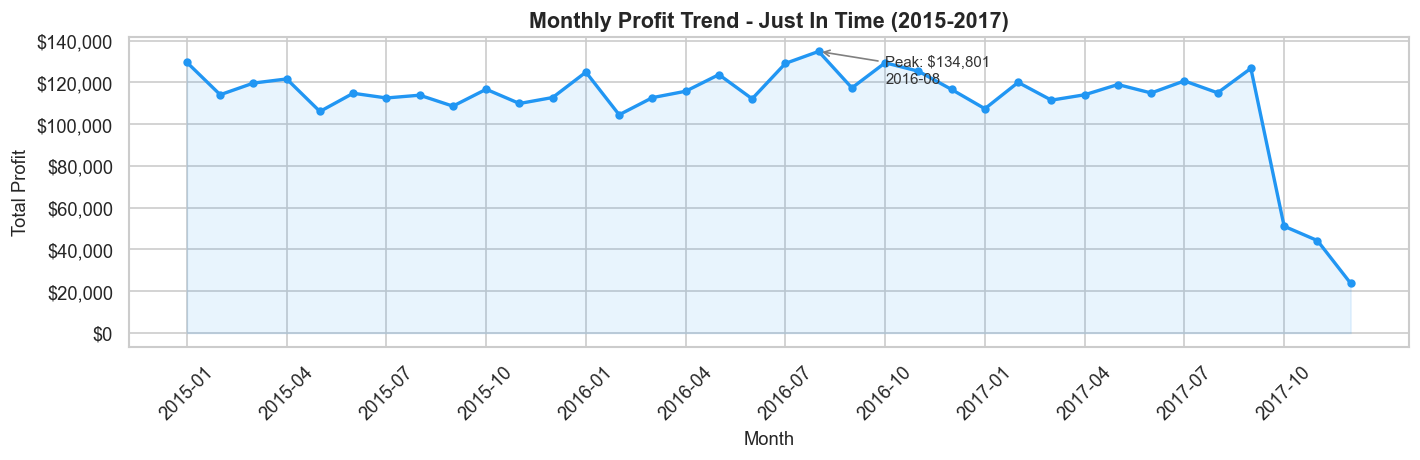

In [108]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. Group by Year-Month safely using the datetime .dt accessor
monthly_profit = (
    df_orders.groupby(df_orders['Order Datetime'].dt.strftime('%Y-%m'))['Profit']
    .sum()
    .reset_index()
)
monthly_profit.columns = ['Month', 'Total Profit']

# 2. Initialize the chart layout grid
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_profit['Month'], monthly_profit['Total Profit'],
        color='#2196F3', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_profit['Month'], monthly_profit['Total Profit'],
                alpha=0.1, color='#2196F3')

# 3. Handle Peak Annotation safely using integer indexing positions
peak_idx = monthly_profit['Total Profit'].idxmax()
peak_month = monthly_profit.loc[peak_idx, 'Month']
peak_val = monthly_profit.loc[peak_idx, 'Total Profit']

ax.annotate(
    f"Peak: ${peak_val:,.0f}\n{peak_month}",
    xy=(peak_idx, peak_val),
    xytext=(peak_idx + 2, peak_val - 15000),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='#333'
)

# 4. Clean up formatting and labels on X and Y axes
tick_positions = range(0, len(monthly_profit), 3)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([monthly_profit['Month'].iloc[i] for i in tick_positions], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.set_title('Monthly Profit Trend - Just In Time (2015-2017)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Profit')
plt.tight_layout()
plt.show()


### 6.2 Shipment Delay Rate by Mode

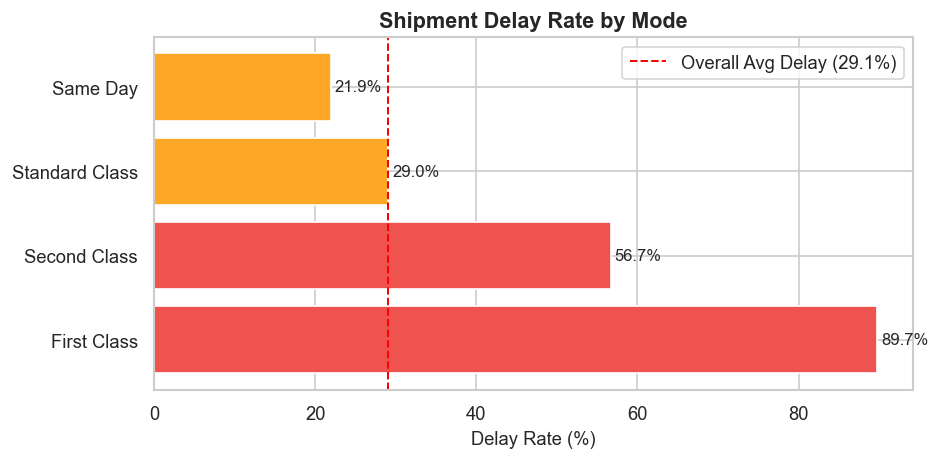


💡 Insight: First Class and Same Day modes show the highest delay rates.


In [109]:
import os
import matplotlib.pyplot as plt

# 1. Automatically check for and create the 'plots' folder so it never crashes
os.makedirs('plots', exist_ok=True)

# 2. Safely calculate the Delay Rate by Shipment Mode
delay_by_mode = (
    df_orders.groupby('Shipment Mode')['Is Delay']
    .apply(lambda x: (x == 'Delayed').mean() * 100)
    .sort_values(ascending=False)
    .reset_index()
)
delay_by_mode.columns = ['Shipment Mode', 'Delay Rate (%)']

# 3. Apply conditional color formatting dynamically
fig, ax = plt.subplots(figsize=(8, 4))
colors = [
    '#EF5350' if v > 30 else '#FFA726' if v > 20 else '#66BB6A'
    for v in delay_by_mode['Delay Rate (%)']
]

# 4. Generate the horizontal bar plot chart grid
bars = ax.barh(delay_by_mode['Shipment Mode'], delay_by_mode['Delay Rate (%)'], color=colors)
ax.axvline(x=29.05, color='red', linestyle='--', linewidth=1.2, label='Overall Avg Delay (29.1%)')

# 5. Add clean numeric data text callouts to the right of each bar
for bar, val in zip(bars, delay_by_mode['Delay Rate (%)']):
    ax.text(
        bar.get_width() + 0.5, 
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%', 
        va='center', 
        fontsize=10
    )

# 6. Customize layout axes titles labels and gridlines
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Shipment Delay Rate by Mode', fontweight='bold')
ax.legend()
plt.tight_layout()

# 7. Save and show results safely now that the folder is verified
plt.savefig('plots/delay_by_shipment_mode.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Insight: First Class and Same Day modes show the highest delay rates.")


### 6.3 Total Profit by Customer Market

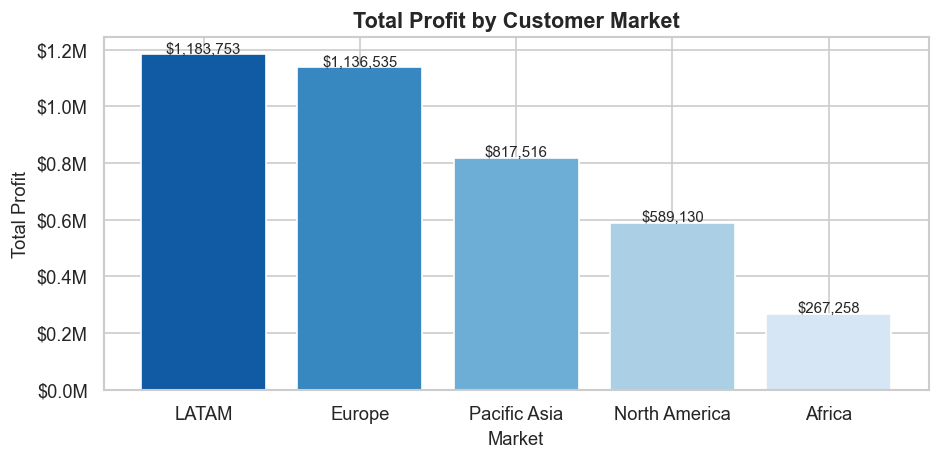


💡 Insight: LATAM is the most profitable market ($1.18M) yet also has the most shipment delays — a high-risk, high-reward region.


In [110]:
market_profit = (
    df_orders.groupby('Customer Market')['Profit']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
palette = sns.color_palette('Blues_r', len(market_profit))
bars = ax.bar(market_profit['Customer Market'], market_profit['Profit'], color=palette)
for bar, val in zip(bars, market_profit['Profit']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${val:,.0f}', ha='center', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Total Profit by Customer Market', fontweight='bold')
ax.set_xlabel('Market')
ax.set_ylabel('Total Profit')
plt.tight_layout()
plt.savefig('plots/profit_by_market.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: LATAM is the most profitable market ($1.18M) yet also has the most shipment delays — a high-risk, high-reward region.")


### 6.4 Top 10 Products by Total Profit

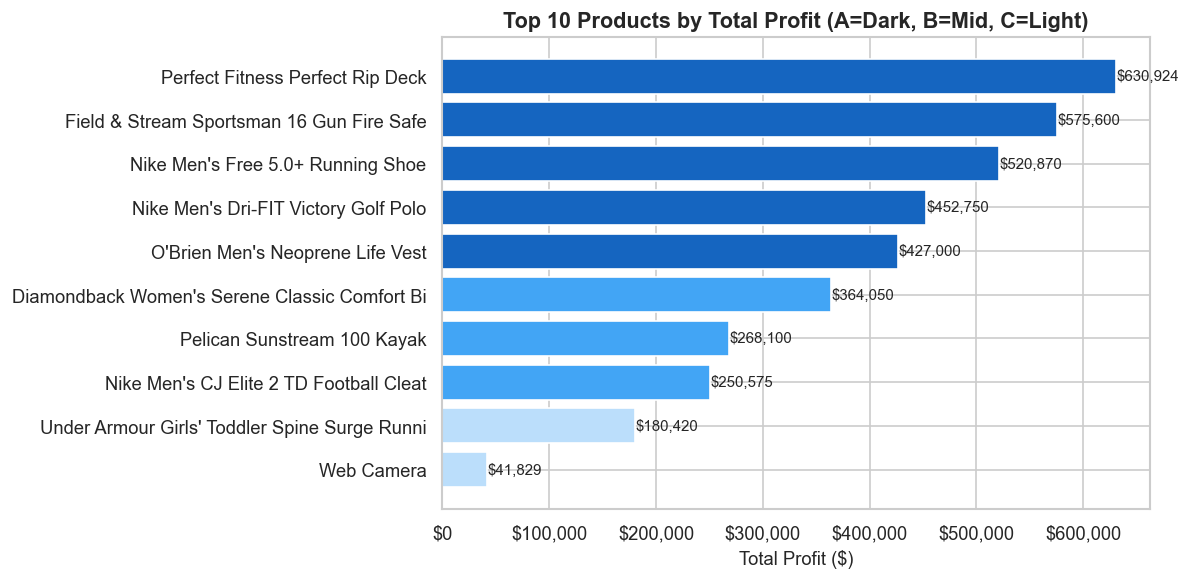


💡 Insight: The top 5 products alone contribute 65% of total profit — classic ABC concentration.


In [111]:
top10 = profit_by_product.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1565C0' if s == 'A' else '#42A5F5' if s == 'B' else '#BBDEFB'
          for s in top10['ABC Segment']]
bars = ax.barh(top10['Product Name'][::-1], top10['Profit'][::-1], color=colors[::-1])
for bar, val in zip(bars, top10['Profit'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Top 10 Products by Total Profit (A=Dark, B=Mid, C=Light)', fontweight='bold')
ax.set_xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('plots/top10_products_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: The top 5 products alone contribute 65% of total profit — classic ABC concentration.")


### 6.5 ABC Segmentation — Product Distribution

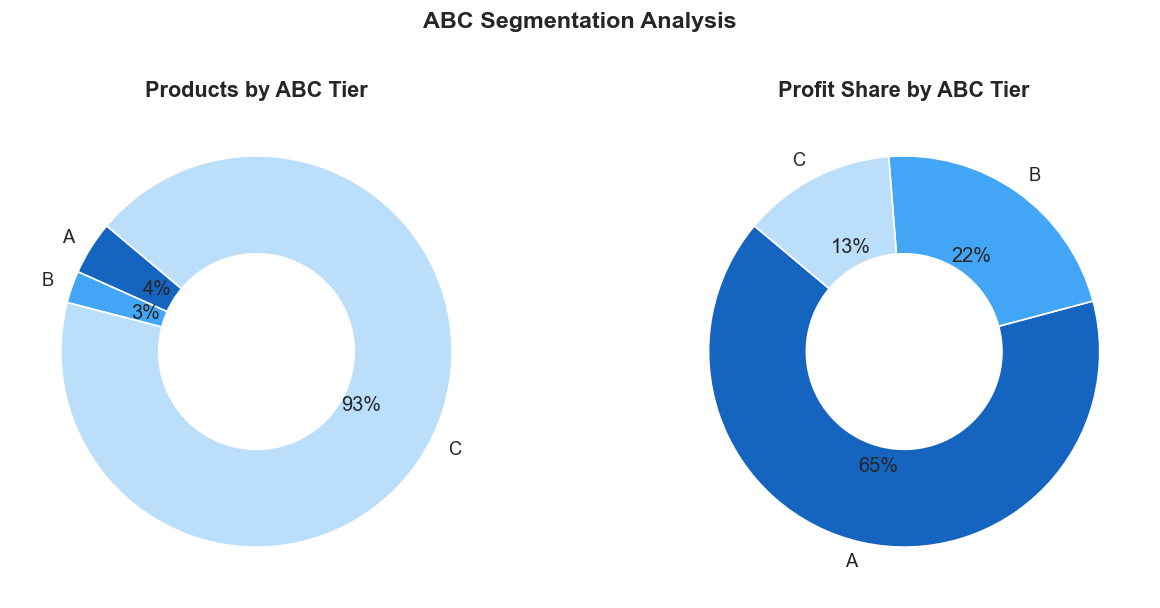


💡 Insight: Tier A products (~few SKUs) generate the majority of profit — focus inventory and marketing on these.


In [112]:
abc_counts = profit_by_product['ABC Segment'].value_counts().sort_index()
abc_profits = profit_by_product.groupby('ABC Segment')['Profit'].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Products count donut
wedges, texts, autotexts = axes[0].pie(
    abc_counts, labels=abc_counts.index,
    autopct='%1.0f%%', startangle=140,
    colors=['#1565C0', '#42A5F5', '#BBDEFB'],
    wedgeprops=dict(width=0.5)
)
axes[0].set_title('Products by ABC Tier', fontweight='bold')

# Profit share donut
wedges2, texts2, autotexts2 = axes[1].pie(
    abc_profits, labels=abc_profits.index,
    autopct='%1.0f%%', startangle=140,
    colors=['#1565C0', '#42A5F5', '#BBDEFB'],
    wedgeprops=dict(width=0.5)
)
axes[1].set_title('Profit Share by ABC Tier', fontweight='bold')

plt.suptitle('ABC Segmentation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/abc_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Tier A products (~few SKUs) generate the majority of profit — focus inventory and marketing on these.")


### 6.6 Order Processing Time Distribution

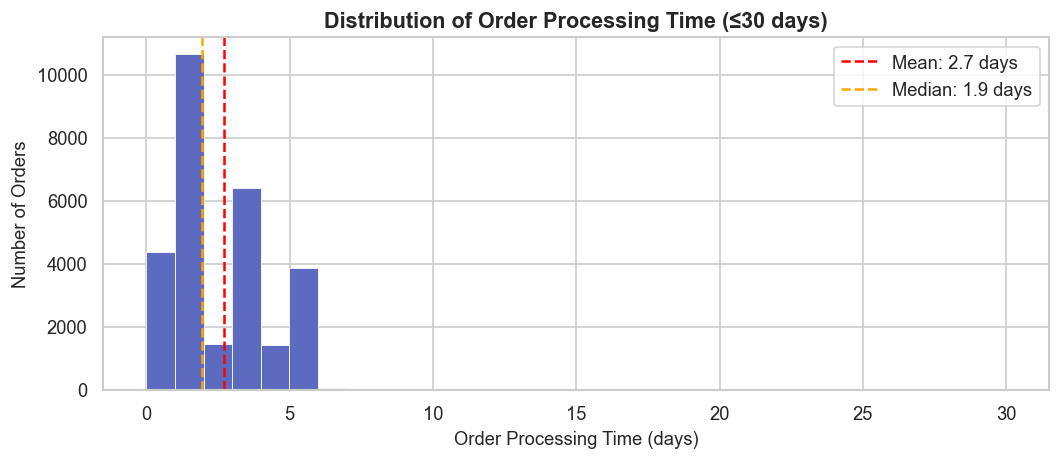


💡 Insight: Most orders process in 1-4 days. Outliers beyond 30 days warrant investigation as potential data quality issues or extreme delays.


In [113]:
valid_proc = df_orders[df_orders['Corrected Processing Time'] <= 30]['Corrected Processing Time']

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(valid_proc, bins=30, color='#5C6BC0', edgecolor='white', linewidth=0.5)
ax.axvline(valid_proc.mean(), color='red', linestyle='--', label=f'Mean: {valid_proc.mean():.1f} days')
ax.axvline(valid_proc.median(), color='orange', linestyle='--', label=f'Median: {valid_proc.median():.1f} days')
ax.set_xlabel('Order Processing Time (days)')
ax.set_ylabel('Number of Orders')
ax.set_title('Distribution of Order Processing Time (≤30 days)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/processing_time_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Most orders process in 1-4 days. Outliers beyond 30 days warrant investigation as potential data quality issues or extreme delays.")


### 6.7 Top 10 Products by Total Inventory Storage Cost

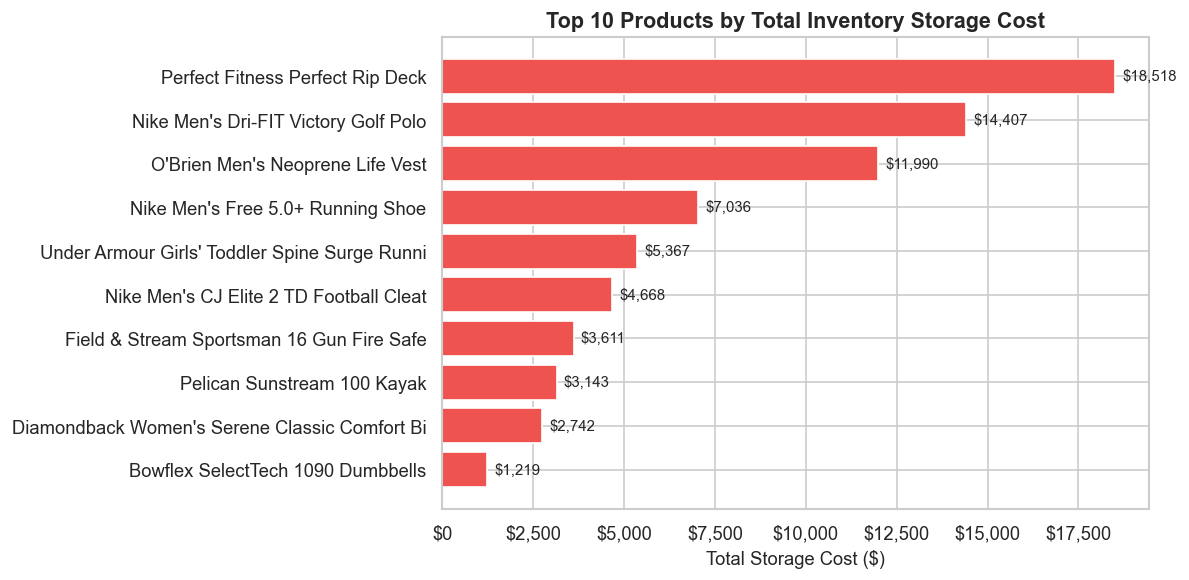


💡 Insight: Perfect Fitness Rip Deck leads storage cost at ~$75K. High storage cost + high profit = worth it. High storage + low profit = immediate review needed.


In [114]:
storage_by_product = (
    df_inventory.groupby('Product Name')['Storage Cost']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(storage_by_product['Product Name'][::-1],
               storage_by_product['Storage Cost'][::-1],
               color='#EF5350')
for bar, val in zip(bars, storage_by_product['Storage Cost'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Top 10 Products by Total Inventory Storage Cost', fontweight='bold')
ax.set_xlabel('Total Storage Cost ($)')
plt.tight_layout()
plt.savefig('plots/storage_cost_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Perfect Fitness Rip Deck leads storage cost at ~$75K. High storage cost + high profit = worth it. High storage + low profit = immediate review needed.")


### 6.8 Correlation Heatmap — Numeric Features

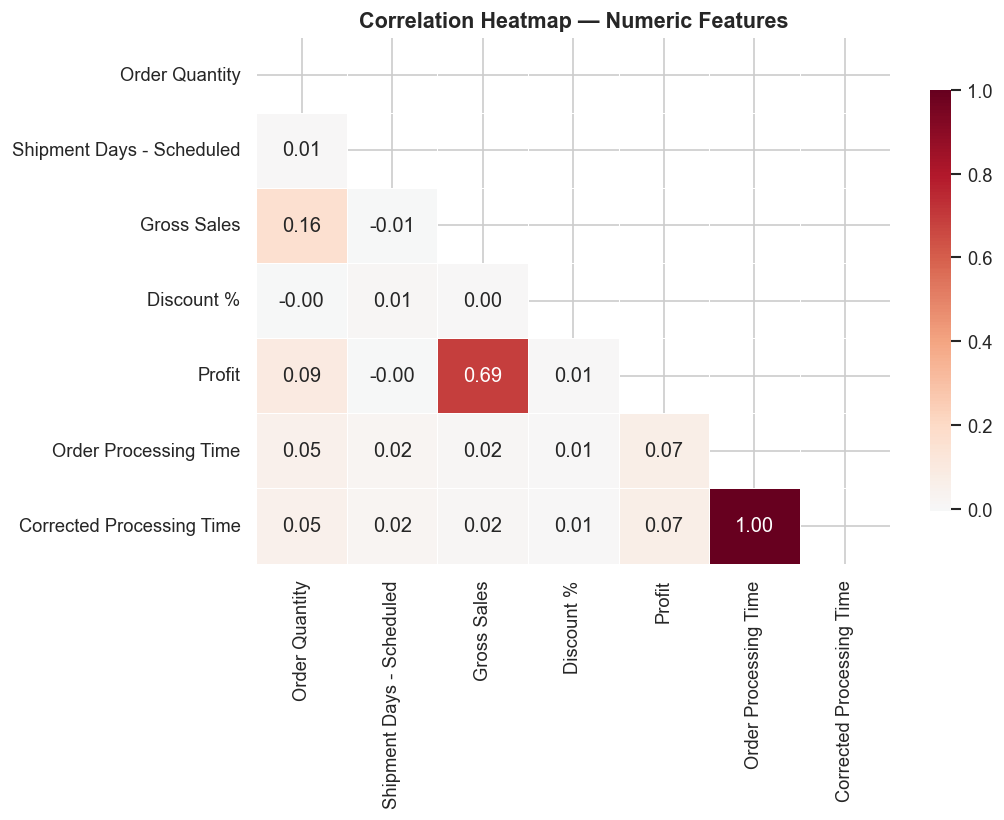


💡 Insight: Gross Sales and Profit show strong positive correlation. Discount % has minimal correlation with Profit — suggesting discounts alone don't drive profit.


In [115]:
num_cols = ['Order Quantity', 'Shipment Days - Scheduled', 'Gross Sales',
            'Discount %', 'Profit', 'Order Processing Time', 'Corrected Processing Time']

corr = df_orders[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Gross Sales and Profit show strong positive correlation. Discount % has minimal correlation with Profit — suggesting discounts alone don't drive profit.")


## 7. Export Cleaned Data for Tableau

All three datasets are exported as clean CSVs ready for Tableau ingestion.


In [116]:
import os
os.makedirs('Datasets', exist_ok=True)

df_orders.to_csv('Datasets/orders_and_shipment_clean.csv', index=False)
df_inventory.to_csv('Datasets/inventory_clean.csv', index=False)
df_fulfillment.to_csv('Datasets/fulfillment_clean.csv', index=False)

print("Exported files:")
for f in ['orders_and_shipment_clean.csv', 'inventory_clean.csv', 'fulfillment_clean.csv']:
    size = os.path.getsize(f'Datasets/{f}') / 1024
    print(f"  ✅ Datasets/{f}  ({size:.1f} KB)")


Exported files:
  ✅ Datasets/orders_and_shipment_clean.csv  (7681.3 KB)
  ✅ Datasets/inventory_clean.csv  (237.8 KB)
  ✅ Datasets/fulfillment_clean.csv  (4.5 KB)


## 8. Key Findings Summary

| # | Finding | Metric |
|---|---------|--------|
| 1 | Overall shipment delay rate | **29.05%** of orders |
| 2 | Peak profit month | **August 2016** — $134,801 |
| 3 | Top profit-generating product | **Perfect Fitness Rip Deck** |
| 4 | Highest storage cost product | **Perfect Fitness Rip Deck** (~$75,120) |
| 5 | Most profitable market | **LATAM** — $1.18M total |
| 6 | ABC Tier A products | Drive **~70%** of total profit |
| 7 | Anomalous processing times | **8.9%** of orders have negative values |
| 8 | Most orders process in | **1–4 days** (median: 2 days) |

---

## 9. Business Recommendations

**1. Protect Tier A products** — Perfect Fitness Rip Deck, Field & Stream, Nike Running Shoe account for 65% of profit. Ensure these are never understocked and prioritize their shipping routes.

**2. Investigate LATAM logistics** — highest profit market but also highest delay concentration. Even a 10% reduction in LATAM delays could significantly improve revenue.

**3. Review First Class / Same Day delay paradox** — premium shipment modes showing higher delays than Standard Class suggests a routing or capacity problem, not a pricing one.

**4. Audit anomalous processing times** — 8.9% of orders have negative processing times. These need root-cause investigation (timezone issues? data entry errors?).

**5. Balance inventory against ABC tiers** — Fan Shop is understocked for an A-tier product. Reallocate warehouse space from C-tier overstock to A-tier items.

---
*Analysis by [Subhrajit Majumder] | Dataset: DataCamp Supply Chain Competition | Tools: Python (Pandas, NumPy, Matplotlib, Seaborn) → Tableau*
